# Bipartite graphs: from interactions to recommendations

Complete Tier B MovieLens 100K lab, with Tier C synthetic mechanism checks. Full five-fold experiment runs by default; no GPU is needed. Three TODOs implement the live graph/scorer. No repository imports. Download the archive directly from GroupLens; acknowledge Harper & Konstan (2015), DOI 10.1145/2827872. Teacher results below are explicitly frozen. Learner mastery remains PENDING_WRITTEN_DEFENSE.

In [ ]:
# @colab-bootstrap
import os,sys,subprocess
os.environ.update(OPENBLAS_NUM_THREADS='1',OMP_NUM_THREADS='1',MKL_NUM_THREADS='1')
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable,'-m','pip','install','numpy==2.2.6','torch==2.8.0','torch-geometric==2.6.1'])
import importlib.metadata as metadata
print({k:metadata.version(k) for k in ['numpy','torch','torch-geometric']})


<div class="package-links"><strong>Your tangible win:</strong> turn an interaction table into a typed graph, prove its prediction targets are hidden, and produce a full-catalog recommendation baseline.<br><a href="https://avistian.github.io/relational/labs/0095-bipartite-graphs.ipynb">Student notebook</a> · <a href="https://avistian.github.io/relational/labs/html/0095-bipartite-graphs.html">Executed lab</a> · <a href="https://avistian.github.io/relational/reference/bipartite-contract.html">Reference sheet</a> · <a href="https://avistian.github.io/relational/labs/l095-reproduction.md">Reproduction contract</a></div>



## 1 · Retrieve before reading

**Cold retrieval:** attempt the three written questions before reading their answers.

Close the preceding lessons. Write three answers: What distinguishes an edge used for message passing from an edge used as a prediction label? Why is a reverse relation still information about the original interaction? What does an off-diagonal entry of a two-step path matrix count?

<details><summary>Check after attempting</summary><p>A message-passing edge is visible input to an encoder; a prediction label is an outcome whose availability depends on the split. A reversed rating identifies the same user–item event. In an unweighted graph, an off-diagonal two-step product counts connecting length-two walks, such as shared items. Correct recognition is not yet a written defense.</p></details>

**The bridge.** [L087](https://avistian.github.io/relational/lessons/0087-link-prediction.html) separated graph input, targets and ranking candidates. [L091](https://avistian.github.io/relational/lessons/0091-r-gcn.html) made relation meaning explicit; [L094](https://avistian.github.io/relational/lessons/0094-hin-survey.html) separated routes from encoders. Here there are only two entity types, but that simplicity does not choose the target or the evaluation protocol for us. This is the foundation for database recommendation in L138 and L144.

**Core route:** sections 2–6 establish the graph and one prediction. Then complete the three notebook tasks. Sections 7–9 explain the full experiment and evidence. Ask the agent about any step that you cannot trace yourself.

<!-- depth-walkthrough:start -->


## The big picture · recommendation needs a path back to items

<div class="learning-route"><p class="route-kicker">THE BIG PICTURE · 095 / TYPED INTERACTIONS</p><p><strong>Bring forward:</strong> L092 separated path instances from endpoint projections. Here users and items occupy different identity spaces. <strong>Follow:</strong> fitting interactions → normalized transitions → three-hop item scores → seen-item mask → ranking metric. <strong>Carry forward:</strong> L097 replaces this fixed scorer with a learned pairwise scorer while keeping candidate eligibility explicit.</p><p><a href="https://avistian.github.io/relational/lessons/0092-meta-paths.html">L092: projected neighborhoods</a> · <a href="https://avistian.github.io/relational/lessons/0087-link-prediction.html">L087: hidden edge boundaries</a> · <a href="https://avistian.github.io/relational/lessons/0097-negative-sampling.html">L097: learned ranking</a> · <a href="https://avistian.github.io/relational/reference/0091-0100-model-map.html">Sequence map</a></p></div>

<figure class="model-map"><div class="model-map-scroll" tabindex="0" role="region" aria-label="Scrollable architecture: Bipartite recommendation · return to an item">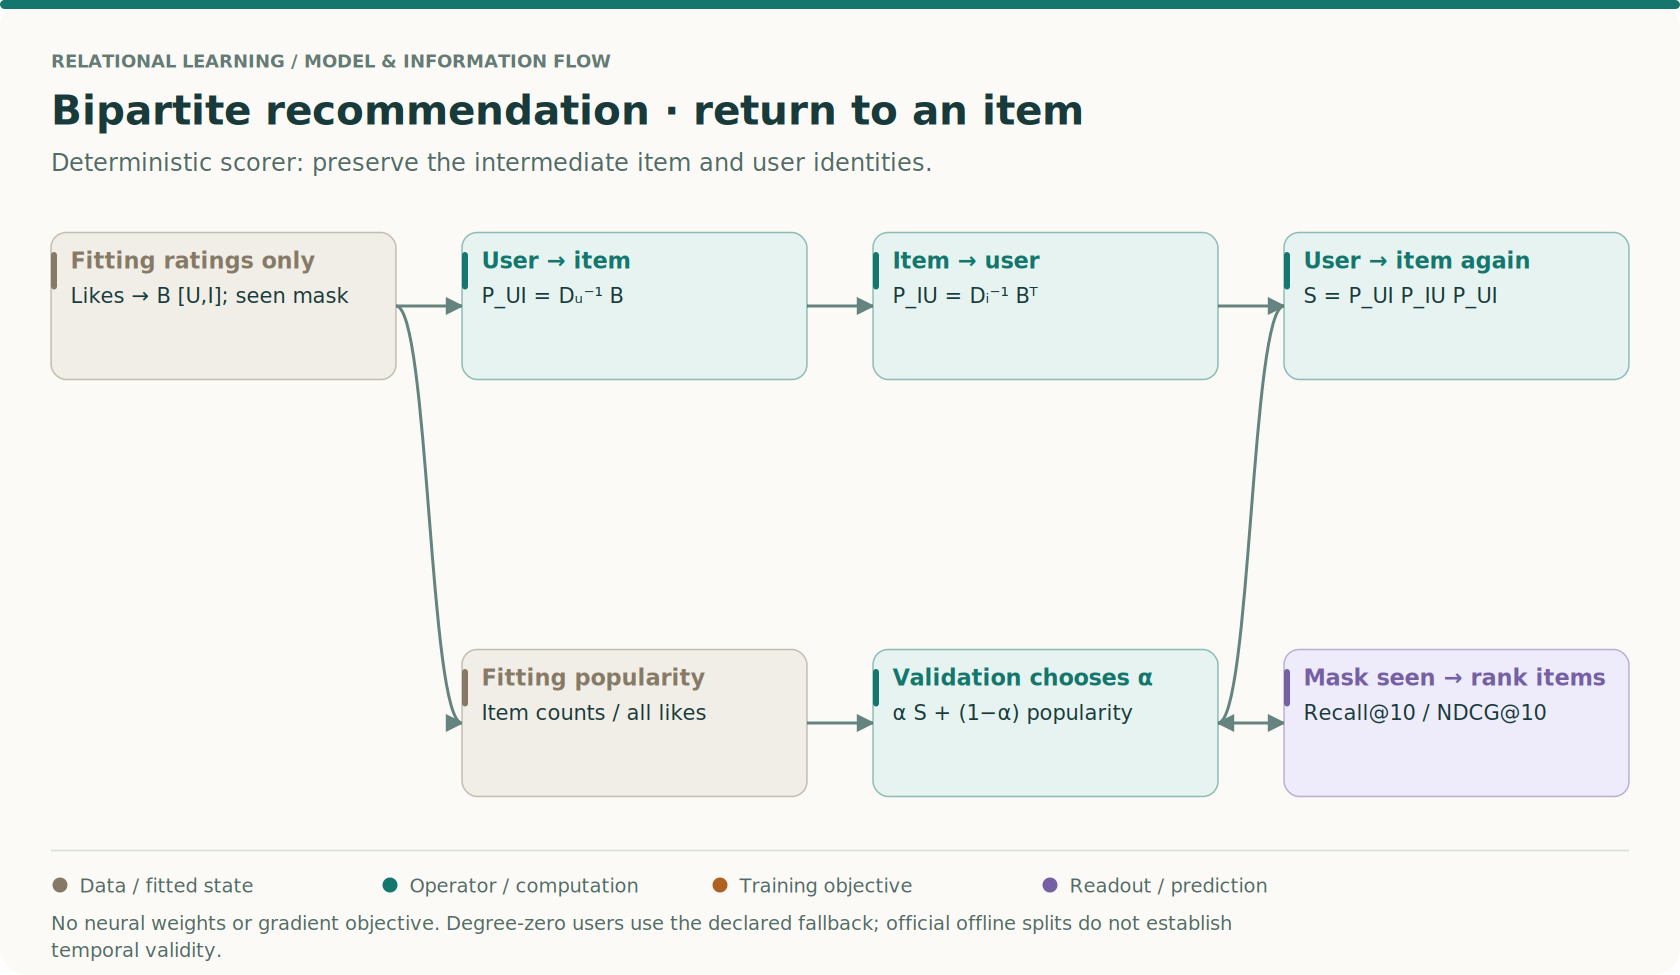</div><figcaption>Deterministic scorer: preserve the intermediate item and user identities. No neural weights or gradient objective. Degree-zero users use the declared fallback; official offline splits do not establish temporal validity.</figcaption></figure>

### Start with the output shape

For U users and I items, a recommender must eventually produce scores indexed by `(user,item)`. A user–user matrix is not that output, even when it captures useful similarity. This shape check forces an explicit final operation that returns from similar users to candidate items. Keep the types beside every multiplication: `[U,I] × [I,U] × [U,I] → [U,I]`.

The first transition chooses an item associated with the starting user. The second chooses another user associated with that item. The third chooses an item associated with that user. Intermediate identities remain meaningful, and degree normalization decides how much probability each step contributes. The diagram shows a deterministic baseline: its counts are fitted state, but it has no learned neural weight matrices or training loss.

### Work through the mass, then apply eligibility

Use two users and three items: u0 likes i0/i1; u1 likes i1/i2. Starting from u0 gives first-hop probabilities `[1/2,1/2,0]`. The first item returns to u0 with certainty; the shared item divides its mass between u0 and u1. After two steps, user probabilities are `[3/4,1/4]`. One more user-to-item step gives `[3/8,1/2,1/8]`.

Those scores sum to one before masking. Masking the two seen items leaves only i2 eligible, with score 1/8. Ranking does not require renormalizing the remaining mass to one. If you do renormalize for presentation, do not mistake the new number for a calibrated purchase probability. The model describes a walk on observed likes, not an exposure or causal preference model.

Now compare a two-hop user projection. `B Bᵀ` gives `[[2,1],[1,2]]`. It preserves shared-item counts, but the value 1 does not name the shared item. A high-degree item creates many user pairs and can inflate projection size. Preserving the bipartite graph keeps the normalization at each actual step inspectable.

### One interaction has several representations

A raw rating row has user, item, rating and timestamp. The fitting graph retains likes under the stated threshold; the seen mask retains every fitting-rated item, including dislikes. These structures answer different questions. A low rating may contribute no positive walk edge while still excluding an item from recommendations. Derive both from the same fitting partition, not from the full release.

The [GroupLens README](https://files.grouplens.org/datasets/movielens/ml-100k-README.txt) defines the release and split files. It does not declare this course's like threshold, mixture-selection rule or ranking protocol. Keep released facts distinct from our experimental choices. Likewise, a successful official-split audit does not establish a valid future-purchase evaluation.

<details><summary>Predict first: what if a held-out like remains only in the reverse store?</summary><p>The graph still contains the withheld fact. A message or walk can use its reverse direction even if the forward entry was removed. Split raw interaction identities first and generate both directions from the allowed fitting rows.</p></details>

**Bridge to L096 and L097.** Database association rows may represent repeated events, quantities or timestamps; collapsing them to one binary edge loses those distinctions. A learned ranking objective then chooses which unobserved pairs to compare against positives. Before either extension, defend the current scorer's cold-user fallback, catalog mask and metric denominator. Ask the teacher to change one of those assumptions and predict which number in the trace moves.

<!-- depth-walkthrough:end -->



## 2 · Begin with a row, not a network

**Worked example.** An interaction row is `(user=17, item=17, rating=5, timestamp=t)`. The repeated number does not identify one entity. `user:17` and `item:17` live in separate namespaces. A **bipartite graph** has two disjoint node sets, users U and items I, and every edge connects the sets. There are no direct user–user or item–item edges in this representation.

**Choose edge meaning.** A rating event records an observed rating. A like in this lab means a rating of at least four. Those are different relations. We keep all observed rating rows for exclusion rules, but only likes become graph edges. A rating of one is therefore absent from the likes graph and still known to the system. An unobserved pair has no observed rating; it is not a proven dislike.

**Choose event policy.** MovieLens 100K has one row per user–item pair; our full audit checks that. If a purchase log repeats pairs, decide whether you predict first purchase, repeat purchase, counts or individual events before collapsing rows. Summing repeated interactions and silently calling the result binary changes the task.

**The tool contract.** PyG `HeteroData` stores node types separately and indexes a relation with a `(source type, relation, destination type)` triple. Each `edge_index` column holds one pair of type-local IDs. Here the forward relation is `('user','likes','item')`; its reverse is `('item','rev_likes','user')`. Store node counts explicitly so isolated users and items are retained. [PyG heterogeneous data guide](https://pytorch-geometric.readthedocs.io/en/latest/tutorial/heterogeneous.html).

```python
# Type-local IDs; zero-based after loading the release.
graph['user'].num_nodes = 943
graph['item'].num_nodes = 1682
# edge_index has shape [2, number_of_likes].
# Its first row indexes users; its second row indexes items.
```

> **In plain terms.** A user and a movie may share the number zero without being the same thing. Adding an edge `(0,0)` connects two entities; it is not a self-loop.



## 3 · See what a projection keeps—and throws away

Let **B** be the binary user–item matrix. It has one row per user, one column per item, and B[u,i]=1 exactly when fitting data contains a like. The transpose Bᵀ swaps rows and columns. In our worked graph, u0 likes i0 and i1; u1 likes i1 and i2.

<figure class="mpnn-figure"><div class="figure-scroll" tabindex="0">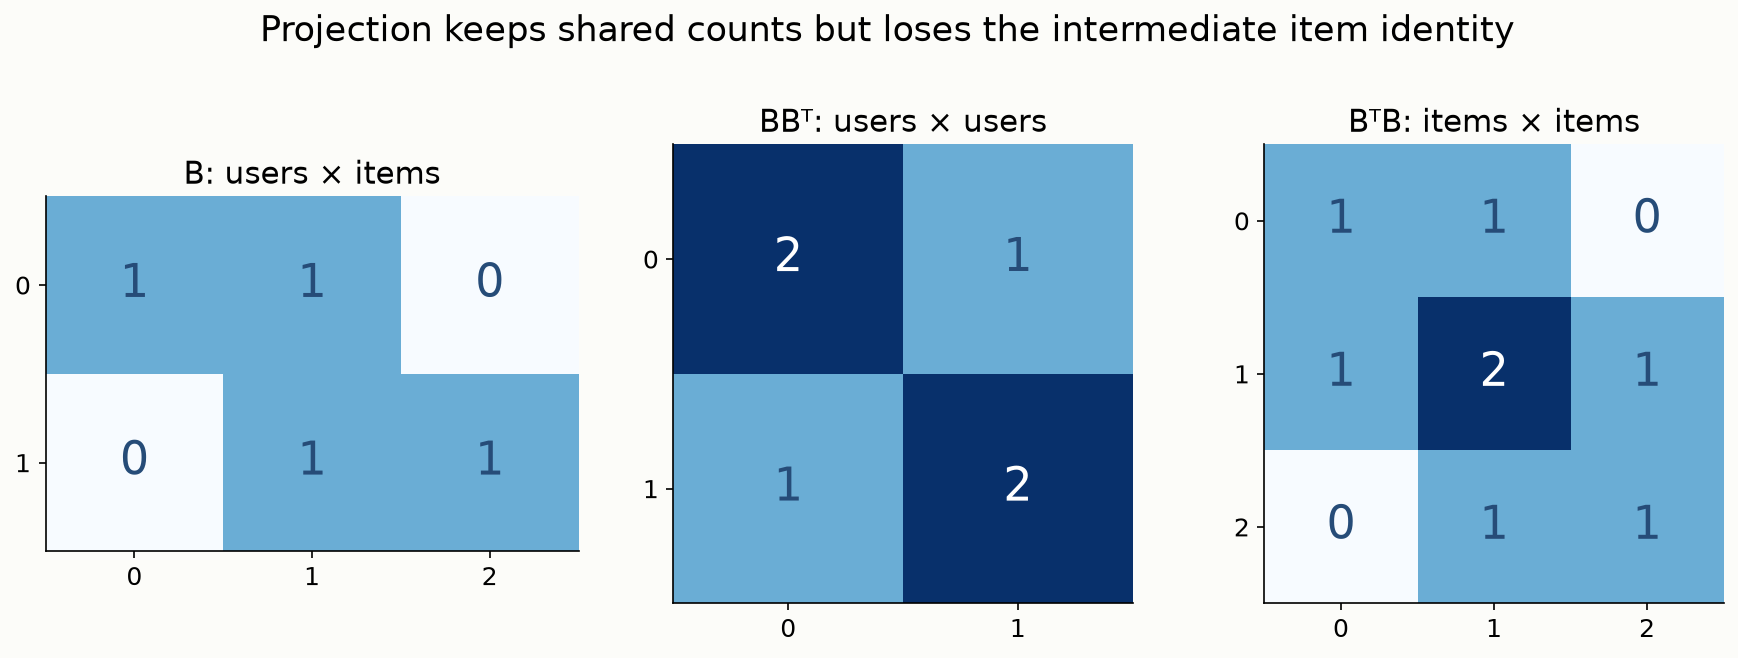</div><figcaption>Synthetic binary B and both projections. The off-diagonal shared-user/item counts differ from original interactions.</figcaption></figure>

Multiplying B by Bᵀ gives a user–user matrix. Entry `(u,v)` sums B[u,i]B[v,i] across items i, so it counts shared liked items. In the figure, users 0 and 1 share exactly one item. The diagonal entry is two because each user likes two items. BᵀB similarly counts shared users between items. These are **projections**: derived same-type relations, not original user–item interactions.

**Why keep the original graph?** The count one does not say whether the shared item was i0, i1 or i2. Relabeling item columns leaves BBᵀ unchanged. A popular item also creates many user pairs: an item liked by d users connects d(d−1)/2 unordered distinct pairs in a binary user projection. This can make a sparse interaction table yield a dense derived graph. Keeping B preserves the intermediate identity and allows normalization at the item step.

**Checkpoint.** If B has shape 943×1682, what are the shapes of BBᵀ and BᵀB? Which one can directly name a recommended item? Answer: 943×943 and 1682×1682. Neither alone is a user–item score matrix; you need an explicit handoff back to items.



## 4 · Split interaction identities before constructing graph views

> **In plain terms.** Hiding the answer means hiding every graph view that reveals the answer.

Separate three objects:

1. **Fitting graph:** likes observed in fitting rows, plus their exact reversed copies. Degrees, transitions and popularity are computed here.
2. **Target rows:** held-out interactions used to assess predictions. Likes among these rows define relevant items.
3. **Candidate set:** items the recommender is allowed to rank. Here it is the fixed catalog minus every item this user already rated in fitting data.

If `(u0,i2)` is held out, remove it from the forward graph **and** remove `(i2,u0)` from the reverse graph. Constructing both directions from an already-split fitting table is easier to audit than deleting individual columns from two independently built stores. The notebook task compares the pair sets and rejects held-out overlap.

**Intervention:** the CHECK below introduces a reverse-only leak. Predict which assertion rejects it.

**Library trap.** If you use PyG `RandomLinkSplit`, explicitly pair `edge_types` and `rev_edge_types`. Its `is_undirected` option alone is ignored for bipartite edge types. `disjoint_train_ratio` separately controls whether training supervision edges are shared with the training message graph. Our experiment uses the official release files and no learned edge classifier, so it does not replace them with this transform. [PyG 2.8.0 RandomLinkSplit](https://pytorch-geometric.readthedocs.io/en/2.8.0/generated/torch_geometric.transforms.RandomLinkSplit.html).

**Time is another boundary.** The official splits are offline rating-completion splits, not a forecasting simulation. Training rows can occur later than a target's timestamp. Reusing their scores as evidence for “predict the next purchase” would change the claim. A temporal experiment needs a cutoff, point-in-time features, catalog availability and an explicit repeat-event policy. IDs being known does not make future interactions admissible.



## 5 · Model architecture: a transparent three-hop baseline

This lesson introduces a deterministic graph scorer, not a neural architecture. Its fitted state consists of counts and transition probabilities. There are no learned embeddings, loss gradients, epochs or optimizer. The selection objective is validation NDCG@10, defined below. Popularity provides a baseline with no user-specific walk.

<figure class="mpnn-figure"><div class="figure-scroll" tabindex="0">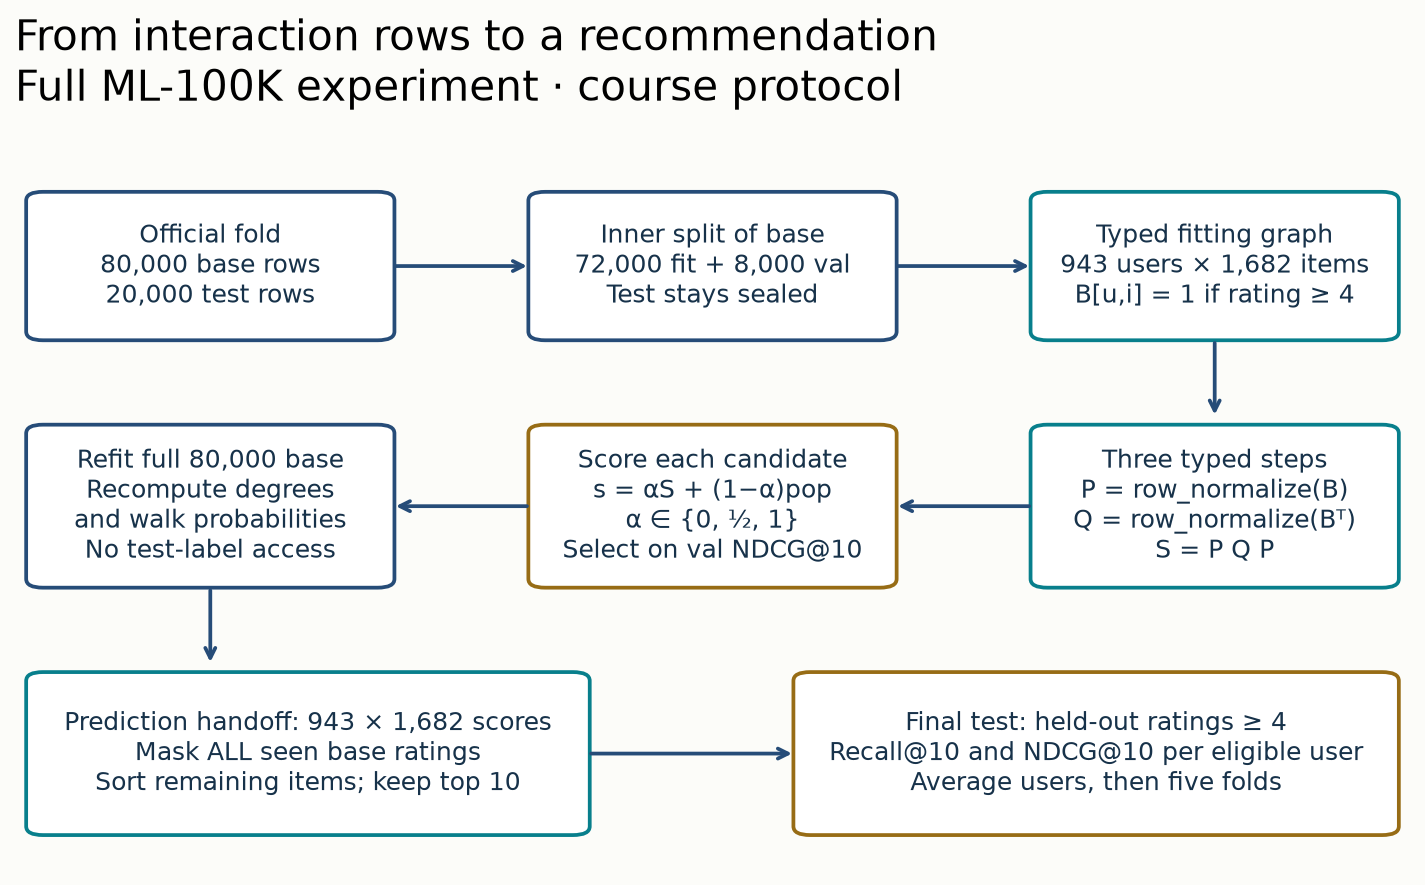</div><figcaption>Complete course protocol. The official test stays hidden during fitting and mixture selection.</figcaption></figure>

**Step 1: normalize outgoing choices.** A walk chooses uniformly among a user's liked items. If dᵤ is that user's fitting like count, P[u,i]=B[u,i]/dᵤ. An item then chooses uniformly among its liking users: Q[i,u]=B[u,i]/dᵢ, where dᵢ is its fitting like count. P has shape U×I and Q has shape I×U. Zero-degree rows initially contain zeros.

**Step 2: compose typed steps.** The product S=PQP has shape U×I. Each entry adds probabilities of all user→item→user→item walks with those endpoints. The matrix PQ is a normalized user–user intermediate, but the final multiplication returns to items. The mechanism therefore retains the bipartite route throughout the computation.

<figure class="mpnn-figure"><div class="figure-scroll" tabindex="0">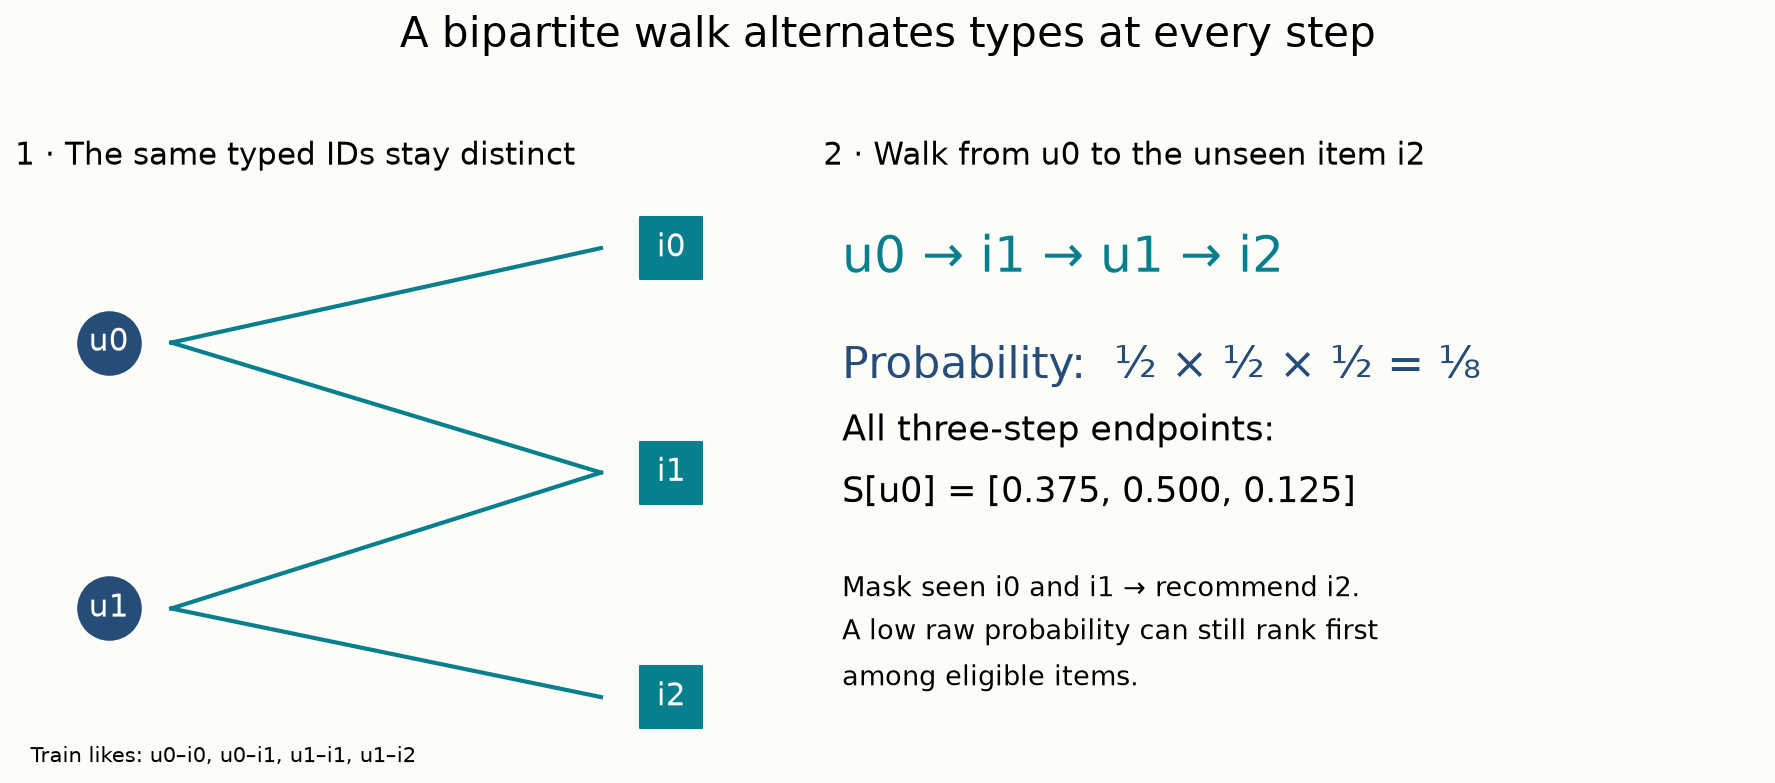</div><figcaption>Synthetic worked graph: u0→i1→u1→i2 has probability 1/8 before candidate masking.</figcaption></figure>

**Worked trace.** In the pictured graph, u0→i1 has probability 1/2. Item i1 chooses u1 with probability 1/2. User u1 chooses i2 with probability 1/2. This is the only three-step path from u0 to i2, so S[u0,i2]=1/8. Summing all paths gives S[u0]=[3/8,1/2,1/8]. Once i0 and i1 are masked as seen, i2 ranks first.

**Cold users and zero-degree items.** A user with no fitting likes gets the fitting-popularity distribution. Popularity is an item's fitting like count divided by the total fitting likes. With no likes anywhere, use a uniform catalog distribution. An item with zero fitting likes receives zero walk/popularity mass, but remains a candidate. Item-ID tie-breaking makes that behavior reproducible; it is not a useful cold-item model.

**Predict before executing:** does removing u1–i1 change S[u0,i2] from 1/8 to zero? Explain the path.

**Portable intervention:** the later cell removes the bridge and recomputes both walks.

**Visible implementation map.** In the notebook, `build_graph` implements typed identity and both edge views; `assert_boundary` enforces the split; `walk_scores` implements the three transitions. These are your three live tasks. The provided `rank_metrics` and `run_experiment` call those functions directly. No imported model hides the computation.



## 6 · A good score needs a defined denominator

A recommender produces an ordered list of eligible item IDs. Here we score all 1,682 catalog items and exclude **every** fitting-rated item for the user, including low ratings. We do not sample a small set of convenient negatives. Unobserved candidates count as nonrelevant for this offline metric because relevance is defined by held-out likes; that convention does not establish real-world dislike.

**Recall@10.** For a user, divide the number of relevant items in the top ten by their total number of held-out relevant items. If two relevant items exist and one is retrieved, recall is 1/2. The result rewards finding more of the user's held-out likes.

**NDCG@10.** Discount a relevant item at rank r by 1/log₂(r+1), with ranks starting at one. Sum those contributions over the top ten to get DCG. Divide by the ideal DCG, which would place up to ten relevant items first. NDCG therefore rewards placing relevant items earlier. With two relevant items and only rank one relevant in top two, DCG=1, ideal DCG=1+1/log₂(3), and NDCG≈0.613.

**Macro averaging.** Compute each eligible user's metric, then average users equally. Users with no held-out likes are excluded and counted explicitly; assigning them zero would change the question. We report each official fold and the mean across folds. Deterministic score ties prefer the smaller item ID. These choices are part of the experiment, not evaluator trivia.

**CHECK before running.** If the top-scoring item was already rated one star in training, is it eligible? No: absence from the likes graph does not erase its observed status. If the target pair already occurs in fitting data, the evaluator rejects the experiment instead of concealing the overlap with a mask.



## 7 · Full reproduction: exactly what was run

**Primary source assignment.** Read the [GroupLens ML-100K README](https://files.grouplens.org/datasets/movielens/ml-100k-README.txt), especially `u.data` and `u1.base` through `u5.test`, then inspect the notebook audit. The released data contain 100,000 ratings, 943 users and 1,682 items; each user has at least 20 ratings. The five supplied splits contain 80,000 fitting and 20,000 test rows each, with disjoint test sets. The audit checks those targets, uniqueness, full row content and reconstruction—not just file sizes.

**Published target: complete data contract.** All counts and all five partitions matched. The minimum observed rating count per user was exactly 20. The five test sets collectively reconstruct all 100,000 original rows. Archive and member SHA-256 fingerprints are in the [source manifest](https://avistian.github.io/relational/labs/_sources_l095.json).

**Course experiment: complete recommendation protocol.** Within each official base, reserve 8,000 rows for validation with declared seed 9501–9505; fit on 72,000. Select α from {0,½,1} using mean validation NDCG@10 for the score αS+(1−α)pop. Ties prefer lower α. Refit counts and transitions on all 80,000 base rows, freeze α, and evaluate the complete official test once per predeclared arm. No test tuning, reduced catalog or early stopping is used.

| Method | Recall@10, mean ± fold SD | NDCG@10, mean ± fold SD |
|---|---:|---:|
| popularity | 0.1254 ± 0.0078 | 0.2046 ± 0.0359 |
| walk | 0.2260 ± 0.0152 | 0.3279 ± 0.0423 |
| validation selected | 0.2260 ± 0.0152 | 0.3279 ± 0.0423 |

| Official fold | Eligible test users | Excluded: no held-out likes | Selected α |
|---|---:|---:|---:|
| 1 | 456 | 487 | 1 |
| 2 | 644 | 299 | 1 |
| 3 | 849 | 94 | 1 |
| 4 | 890 | 53 | 1 |
| 5 | 878 | 65 | 1 |

Frozen author-reference measurements; not output from your current notebook kernel. The official folds have different eligible user populations. We retain their released assignments; fold variation includes this composition difference.

<figure class="mpnn-figure"><div class="figure-scroll" tabindex="0">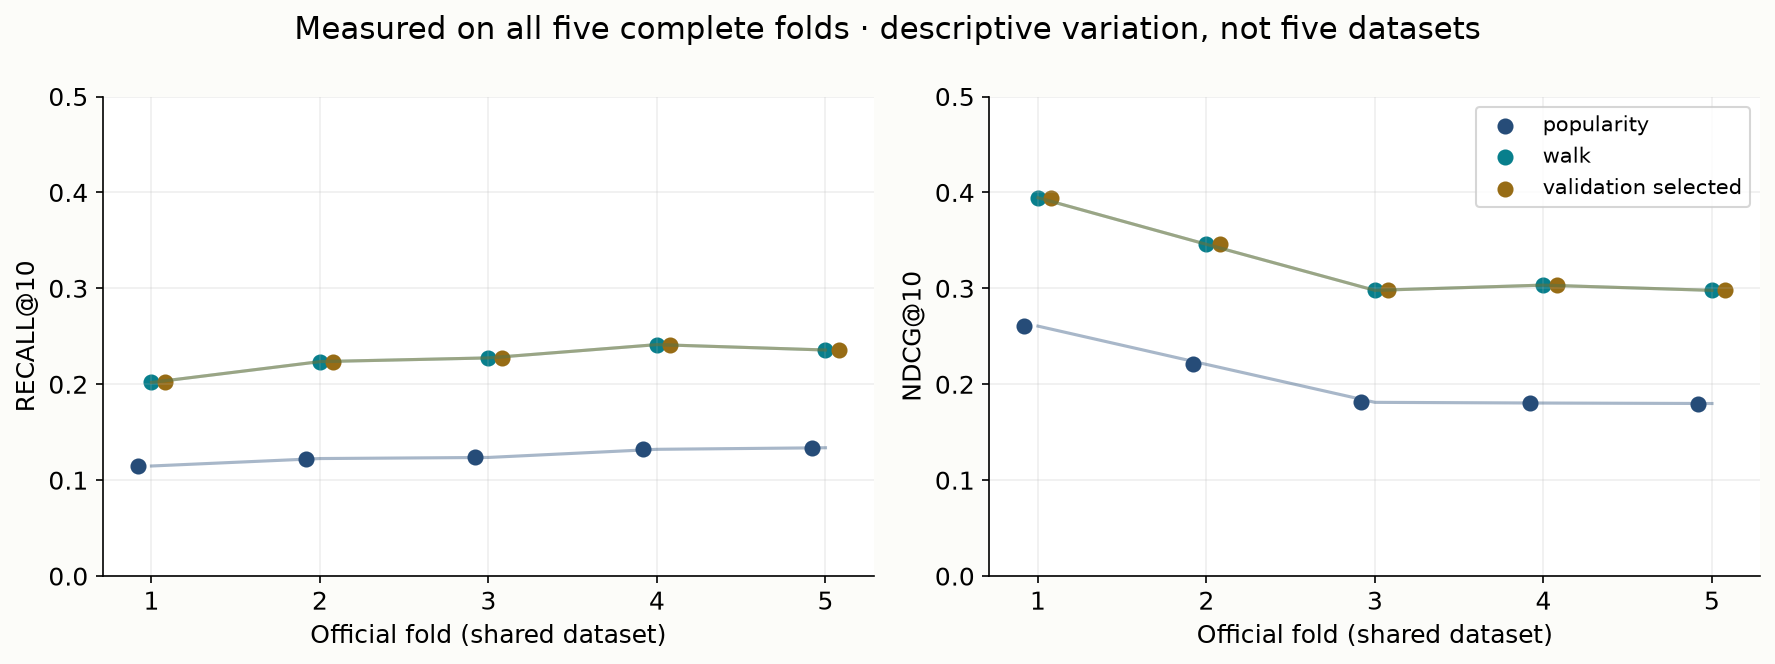</div><figcaption>Fresh author measurements on five complete official folds. Points are fold-level user averages, not independent datasets.</figcaption></figure>

All five folds selected α=1. The selected arm therefore equals the pure walk; it is not a third independent method. The source and full [executed evidence](https://avistian.github.io/relational/labs/_experiment_l095_results.json) record every validation score, fold denominator, source hash and environment. Raw top-ten lists support independent metric reconstruction.

> **Scope check.** These five folds share one dataset and overlapping training data. Their standard deviation describes fold variability; it is not a confidence interval across datasets. The walk beats popularity here, under this protocol. That does not establish that graph neural networks beat tabular models, that relational learning wins broadly, or that a historical model score was reproduced.

**No missing model-paper claim.** The roadmap assigns no model paper to L095. The release audit is `MATCH`; the complete course experiment is `MEASURED`. Historical model-score parity is `NOT_ESTABLISHED` because no corresponding published score/protocol is claimed. Reproducing a later LightGCN or other recommender paper would require that paper's actual model, datasets, split, optimization, selection and metric—not relabeling these numbers. See the [protocol/deviation ledger](https://avistian.github.io/relational/labs/l095-reproduction.md).



## 8 · Lab: implement the contract, then break it deliberately

Open the [student notebook](https://avistian.github.io/relational/labs/0095-bipartite-graphs.ipynb). It contains the complete loader, scorer, evaluator and full five-fold experiment, with portable figures and frozen author-reference results labeled separately from fresh execution.

- **TODO 1 — typed graph.** Validate local IDs, retain isolated nodes, include only fitting likes, and derive the reverse relation. CHECK includes a same-number user/item pair.
- **TODO 2 — information boundary.** Compare both directed stores as user–item pairs, then reject held-out overlap. CHECK corrupts only the reverse store.
- **TODO 3 — walk.** Normalize by the appropriate outgoing degree at each type, compose three steps, and supply the declared cold-user fallback. CHECK independently enumerates the tiny graph's routes.
- **Experiment.** Run all official folds with your functions; inspect validation selection, full-catalog ranking, per-user denominators and result tables. Predict why removing the shared-item bridge changes the tiny walk before executing the intervention.



## 9 · EXIT: defend the graph before claiming the score

Submit your complete run and a short written defense: define the two namespaces; distinguish observed ratings, likes and unknown pairs; explain why reverse edges share a split; state what a projection discards; trace the three-step probability; name the candidate and user denominators; separate the matched published data contract from the course ranking result. Then propose the time cutoff and event policy needed for next-purchase prediction.

**Written defense:** submit the EXIT response to the agent; execution alone is not mastery.

Learner status remains **PENDING_WRITTEN_DEFENSE**. Prepared notebooks and teacher execution do not establish your mastery. Revisit the typed-ID and reverse-leakage questions tomorrow without looking, then trace a different graph one week later.

**Next bridge.** L096 generalizes two entity tables and an interaction relation into SQL primary-key/foreign-key semantics. L097 studies negative sampling, where changing candidates can change the apparent quality of a recommender. This lesson keeps the full catalog so that boundary is explicit.


## Visible implementation and immediate feedback

The data audit reproduces the named release contract; the ranking experiment is course-defined. Every function below is used by the complete run. Implement each task before proceeding to its CHECK.

In [ ]:
import hashlib
import io
import json
import urllib.request
import zipfile
from pathlib import Path
import numpy as np
import torch
from torch_geometric.data import HeteroData
ARCHIVE_URL='https://files.grouplens.org/datasets/movielens/ml-100k.zip'
ARCHIVE_SHA256='50d2a982c66986937beb9ffb3aa76efe955bf3d5c6b761f4e3a7cd717c6a3229'
torch.set_num_threads(1)

### PROVIDED · sha256

Identify exact bytes; neither filename nor row count identifies a dataset.

In [ ]:
def sha256(path):
    """Identify exact bytes; neither filename nor row count identifies a dataset."""
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

### PROVIDED · acquire

Download directly from GroupLens; verify before reading. Do not redistribute data.

In [ ]:
def acquire(path):
    """Download directly from GroupLens; verify before reading. Do not redistribute data."""
    path=Path(path);path.parent.mkdir(parents=True,exist_ok=True)
    if not path.exists():
        tmp=path.with_suffix('.partial')
        urllib.request.urlretrieve(ARCHIVE_URL,tmp)
        if sha256(tmp)!=ARCHIVE_SHA256:
            tmp.unlink();raise ValueError('Downloaded archive hash mismatch')
        tmp.replace(path)
    if sha256(path)!=ARCHIVE_SHA256:raise ValueError('Archive hash mismatch')
    return path

### PROVIDED · read_release

Read full data and all five official splits without extracting the archive.

In [ ]:
def read_release(path):
    """Read full data and all five official splits without extracting the archive."""
    with zipfile.ZipFile(acquire(path)) as z:
        arrays={};hashes={}
        for name in ['u.data']+[f'u{i}.{s}' for i in range(1,6) for s in ['base','test']]:
            raw=z.read('ml-100k/'+name);hashes[name]=hashlib.sha256(raw).hexdigest()
            a=np.loadtxt(io.BytesIO(raw),dtype=np.int64);a[:,:2]-=1;arrays[name]=a
    return arrays,hashes

### PROVIDED · audit_release

Recompute the README's complete counts and five-fold partition contract.

In [ ]:
def audit_release(arrays):
    """Recompute the README's complete counts and five-fold partition contract."""
    full=arrays['u.data'];identities=set(map(tuple,full));pairs=set(map(tuple,full[:,:2]))
    assert len(full)==len(identities)==len(pairs)==100000
    assert set(full[:,0])==set(range(943)) and set(full[:,1])==set(range(1682))
    assert np.all((full[:,2]>=1)&(full[:,2]<=5))
    counts=np.bincount(full[:,0],minlength=943);assert counts.min()>=20
    seen=set();folds=[]
    for fold in range(1,6):
        a,b=arrays[f'u{fold}.base'],arrays[f'u{fold}.test'];sa,sb=set(map(tuple,a)),set(map(tuple,b))
        assert len(a)==len(sa)==80000 and len(b)==len(sb)==20000
        assert not sa&sb and sa|sb==identities and not seen&sb
        seen|=sb;folds.append({'fold':fold,'base':len(a),'test':len(b),'disjoint':True,'reconstructs_full':True})
    assert seen==identities
    return {'status':'MATCH','target':'GroupLens ML-100K README: counts and u1-u5 partitions','ratings':len(full),'users':943,'items':1682,'minimum_user_ratings':int(counts.min()),'folds':folds,'five_test_sets_partition_full':True}

### TODO · build_graph

Validate integer local IDs, rating range and pair uniqueness. Use the declared node counts. Store only ratings ≥4 as forward edges, with the exact reverse. Do not merge the two namespaces.

In [ ]:
def build_graph(rows,n_users,n_items):
    raise NotImplementedError("Complete this task")

### CHECK · build_graph

In [ ]:
tiny=np.array([[0,0,5,1],[0,1,4,2],[1,1,5,3],[1,2,4,4],[2,0,1,5]])
g=build_graph(tiny,4,4)
assert g['user'].num_nodes==4 and g['item'].num_nodes==4
assert g['user','likes','item'].edge_index.shape==(2,4)
assert torch.equal(g['item','rev_likes','user'].edge_index,g['user','likes','item'].edge_index.flip(0))
try:
    build_graph(np.vstack([tiny,tiny[0]]),4,4)
except ValueError:
    print('PASS: repeated pairs rejected; typed IDs and isolated nodes retained')
else:
    raise AssertionError('Repeated pairs need an explicit policy')

### TODO · assert_boundary

Convert both edge stores to user–item pair sets. Reject duplicates, unequal forward/reverse content and any held-out pair in either view. Use assertions so the diagnostic CHECK can distinguish rejection.

In [ ]:
def assert_boundary(graph,heldout):
    raise NotImplementedError("Complete this task")

### CHECK · assert_boundary

In [ ]:
held=np.array([[0,2,5,6]])
assert_boundary(g,held)
bad=g.clone();bad['item','rev_likes','user'].edge_index[0,0]=2
try:
    assert_boundary(bad,held)
except AssertionError:
    print('PASS: reverse-only corruption rejected')
else:
    raise AssertionError('Forward-only checks miss this leak')

### PROVIDED · split_inner

Course validation split within official base; official test is untouched.

In [ ]:
def split_inner(base,seed=95,fraction=.1):
    """Course validation split within official base; official test is untouched."""
    if not 0<fraction<1 or len(base)<2:raise ValueError('Need nonempty fitting and validation rows')
    order=np.random.default_rng(seed).permutation(len(base));n=max(1,min(len(base)-1,int(len(base)*fraction)))
    return base[order[n:]].copy(),base[order[:n]].copy()

### TODO · walk_scores

Construct the binary matrix from the fitting graph. Normalize outgoing choices at each type, compose the three-step walk, and return scores plus fitting-popularity probabilities. Zero-degree users use popularity; if the graph has no likes, use uniform popularity.

In [ ]:
def walk_scores(graph):
    raise NotImplementedError("Complete this task")

### CHECK · walk_scores

In [ ]:
s,p=walk_scores(g)
np.testing.assert_allclose(s[0],[.375,.5,.125,0],atol=1e-12)
np.testing.assert_allclose(s[2:],np.tile(p,(2,1)))
np.testing.assert_allclose(s.sum(1),1)
assert np.isfinite(s).all()
print('PASS: three-step probabilities and cold-user fallback')

### PROVIDED · rank_metrics

Full-catalog user-macro Recall/NDCG; no sampled negatives; stable item-ID ties.

In [ ]:
def rank_metrics(scores,observed,heldout,k=10):
    """Full-catalog user-macro Recall/NDCG; no sampled negatives; stable item-ID ties."""
    scores=np.asarray(scores);nu,ni=scores.shape
    if k<1 or not np.isfinite(scores).all():raise ValueError('Finite scores and positive k required')
    observed=np.asarray(observed);heldout=np.asarray(heldout)
    if set(map(tuple,observed[:,:2]))&set(map(tuple,heldout[:,:2])):raise ValueError('Seen target pair')
    blocked=[set() for _ in range(nu)];truth=[set() for _ in range(nu)]
    for u,i in observed[:,:2]:blocked[int(u)].add(int(i))
    for u,i,r,t in heldout:
        if r>=4:truth[int(u)].add(int(i))
    records=[];ids=np.arange(ni)
    for u in range(nu):
        if not truth[u]:continue
        candidates=ids[~np.isin(ids,list(blocked[u]))]
        top=candidates[np.lexsort((candidates,-scores[u,candidates]))[:k]]
        hit=np.array([i in truth[u] for i in top],dtype=float)
        dcg=float((hit/np.log2(np.arange(len(top))+2)).sum())
        ideal=float((1/np.log2(np.arange(min(k,len(truth[u])))+2)).sum())
        records.append({'user':u,'relevant':len(truth[u]),'candidates':len(candidates),'top_items':top.tolist(),'recall':float(hit.sum()/len(truth[u])),'ndcg':dcg/ideal})
    return {'recall':float(np.mean([x['recall'] for x in records])) if records else None,'ndcg':float(np.mean([x['ndcg'] for x in records])) if records else None,'users':len(records),'excluded_no_relevant':nu-len(records),'k':k},records

### PROVIDED · run_experiment

Select mixture on inner validation; refit full official base; evaluate test once per arm.

In [ ]:
def run_experiment(arrays,output_dir=None):
    """Select mixture on inner validation; refit full official base; evaluate test once per arm."""
    runs=[]
    if output_dir is not None:Path(output_dir).mkdir(parents=True,exist_ok=True)
    for fold in range(1,6):
        base,test=arrays[f'u{fold}.base'],arrays[f'u{fold}.test'];fit,val=split_inner(base,seed=9500+fold)
        graph=build_graph(fit,943,1682);assert_boundary(graph,np.vstack([val,test]))
        w,p=walk_scores(graph);validation=[]
        for alpha in [0.,.5,1.]:
            metrics,_=rank_metrics(alpha*w+(1-alpha)*p[None,:],fit,val)
            validation.append({'alpha':alpha,**metrics})
        # Ties prefer the simpler popularity model (lower alpha).
        chosen=max(validation,key=lambda x:x['ndcg'])['alpha']
        graph=build_graph(base,943,1682);assert_boundary(graph,test);w,p=walk_scores(graph)
        models={};details={}
        for name,alpha in [('popularity',0.),('walk',1.),('validation_selected',chosen)]:
            models[name],details[name]=rank_metrics(alpha*w+(1-alpha)*p[None,:],base,test)
        entry={'fold':fold,'split_seed':9500+fold,'fit_rows':len(fit),'validation_rows':len(val),'refit_rows':len(base),'test_rows':len(test),'graph_like_edges':int(graph['user','likes','item'].edge_index.shape[1]),'alpha':chosen,'validation':validation,'test':models}
        if output_dir is not None:
            path=Path(output_dir)/f'fold-{fold}.json';path.write_text(json.dumps(details,indent=2)+'\n');entry['rankings_sha256']=sha256(path)
            split=Path(output_dir)/f'fold-{fold}-inner.npz';np.savez_compressed(split,fit=fit,validation=val);entry['inner_arrays_sha256']=hashlib.sha256(fit.tobytes()+val.tobytes()).hexdigest()
        runs.append(entry)
    summary={name:{metric:{'mean':float(np.mean([r['test'][name][metric] for r in runs])),'fold_sd':float(np.std([r['test'][name][metric] for r in runs],ddof=1))} for metric in ['recall','ndcg']} for name in ['popularity','walk','validation_selected']}
    return {'status':'MEASURED','scope':'Course ranking protocol on all five complete official ML-100K folds','full_paper_parity':'NOT_APPLICABLE_NO_MODEL_PAPER','historical_model_score_parity':'NOT_ESTABLISHED','runs':runs,'summary':summary,'uncertainty':'Fold SD is descriptive; overlapping training folds are not independent datasets.'}

## Predict → intervene → explain

Remove the u1–i1 bridge, retaining all other likes and the scoring rule. Write your predicted S[u0,i2] before executing. Why does the candidate list, rather than the largest raw probability, determine the recommendation?

In [ ]:
changed=tiny[~((tiny[:,0]==1)&(tiny[:,1]==1))]
new_graph=build_graph(changed,4,4)
new_scores,_=walk_scores(new_graph)
assert s[0,2]==.125 and new_scores[0,2]==0
print('u0 to i2 baseline:',s[0,2],'intervention:',new_scores[0,2])
mask_test=np.array([[0,2,5,6]])
m,d=rank_metrics(s,tiny,mask_test,k=1)
assert d[0]['top_items']==[2]
print('Seen items excluded; top recommendation:',d[0]['top_items'])

## Full released-data target and full course experiment

This is a fresh full run, not frozen evidence. It checks every released fold and scores all eligible users against the complete catalog. Only inner validation chooses the mixture. Refit uses all official base rows. The full loop uses the three functions you implemented.

In [ ]:
archive=Path(os.environ.get('L095_DATA_PATH','ml-100k.zip'))
arrays,member_hashes=read_release(archive)
fresh_audit=audit_release(arrays)
print('Published release contract:',fresh_audit)
fresh=run_experiment(arrays,Path('l095-results'))
Path('l095-fresh.json').write_text(json.dumps({'audit':fresh_audit,'experiment':fresh},indent=2))
for name,row in fresh['summary'].items():
    print(f"{name:22} Recall@10={row['recall']['mean']:.4f} ± {row['recall']['fold_sd']:.4f}; NDCG@10={row['ndcg']['mean']:.4f} ± {row['ndcg']['fold_sd']:.4f}")
for row in fresh['runs']:
    print('Fold',row['fold'],'chosen alpha',row['alpha'],'eligible users',row['test']['walk']['users'])

## CHECK · fresh measurements against labeled author reference

Exact hashes identify the same data. Metrics allow 1e-12 numeric tolerance for the same deterministic protocol; close numbers alone do not establish historical experiment identity.

In [ ]:
AUTHOR_REFERENCE=json.loads('{"popularity": {"recall": {"mean": 0.12538681700211554, "fold_sd": 0.007751940198213933}, "ndcg": {"mean": 0.20455278286752138, "fold_sd": 0.03585218855944913}}, "walk": {"recall": {"mean": 0.2259884679190265, "fold_sd": 0.015160279876732442}, "ndcg": {"mean": 0.32788588132434177, "fold_sd": 0.042299505921037615}}, "validation_selected": {"recall": {"mean": 0.2259884679190265, "fold_sd": 0.015160279876732442}, "ndcg": {"mean": 0.32788588132434177, "fold_sd": 0.042299505921037615}}}')
for name in AUTHOR_REFERENCE:
    for metric in ["recall","ndcg"]:
        np.testing.assert_allclose(fresh["summary"][name][metric]["mean"],AUTHOR_REFERENCE[name][metric]["mean"],atol=1e-12,rtol=0)
print("PASS: fresh full-fold summary agrees with author reference")

## EXIT TICKET · PENDING_WRITTEN_DEFENSE

Paste the run summary and your answers to the agent:

1. Why is (user:0,item:0) not a self-loop?
2. Why must the reverse relation share the forward split?
3. Why mask low-rated fitting items even though they have no likes edge?
4. Trace 1/8 and explain the projection information loss.
5. Define the candidate catalog, relevance convention, eligible users, tie rule and selection boundary.
6. What exactly did the published-data audit reproduce, and what score was not claimed?
7. Specify the cutoff and repeated-event policy needed to turn this into a next-purchase study.

Teacher execution is not evidence of your mastery. Ask follow-up questions wherever you cannot justify a step.